In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("Model building libraries imported successfully!")

Model building libraries imported successfully!


## Model Building - FD001

In this notebook, we build machine learning regression models to predict the Remaining Useful Life (RUL) of turbofan engines.

To avoid data leakage, engines are split at the unit level so that the same engine does not appear in both training and validation sets.

In [2]:
# Load processed FD001 training dataset
data_path = "../data/processed/train_FD001_processed.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (20631, 21)


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,...,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL
0,1,1,-0.0007,-0.0004,100.0,641.82,1589.70,1400.60,21.61,554.36,...,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,642.15,1591.82,1403.14,21.61,553.75,...,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,642.35,1587.99,1404.20,21.61,554.26,...,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,642.35,1582.79,1401.87,21.61,554.45,...,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,642.37,1582.85,1406.22,21.61,554.00,...,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


In [3]:
# Basic verification before model building

print("Number of engines:", df["unit_id"].nunique())
print("Total missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

print("\nRUL statistics:")
print(df["RUL"].describe())

Number of engines: 100
Total missing values: 0
Duplicate rows: 0

RUL statistics:
count    20631.000000
mean       107.807862
std         68.880990
min          0.000000
25%         51.000000
50%        103.000000
75%        155.000000
max        361.000000
Name: RUL, dtype: float64


### Engine-wise Train/Validation Split

A group-based split is used to prevent data leakage. All cycles belonging to a particular engine remain entirely within either the training set or the validation set.

In [4]:
# Create engine-wise train/validation split

splitter = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, val_idx = next(
    splitter.split(
        df,
        groups=df["unit_id"]
    )
)

train_data = df.iloc[train_idx].copy()
val_data = df.iloc[val_idx].copy()

print("Training shape:", train_data.shape)
print("Validation shape:", val_data.shape)

print("\nTraining engines:", train_data["unit_id"].nunique())
print("Validation engines:", val_data["unit_id"].nunique())

Training shape: (16561, 21)
Validation shape: (4070, 21)

Training engines: 80
Validation engines: 20


In [5]:
# Verify that no engine appears in both sets

train_engines = set(train_data["unit_id"].unique())
val_engines = set(val_data["unit_id"].unique())

common_engines = train_engines.intersection(val_engines)

print("Common engines between train and validation:")
print(common_engines)

if len(common_engines) == 0:
    print("\nSplit verification passed!")
else:
    print("\nWarning: Data leakage detected!")

Common engines between train and validation:
set()

Split verification passed!


### Feature and Target Preparation

The model input contains operational settings and non-constant sensor measurements. Engine identifiers and cycle numbers are excluded from the initial feature set, while RUL is used as the regression target.

In [6]:
# Define input features

feature_columns = [
    col for col in df.columns
    if col not in ["unit_id", "cycle", "RUL"]
]

# Create training features and target
X_train = train_data[feature_columns]
y_train = train_data["RUL"]

# Create validation features and target
X_val = val_data[feature_columns]
y_val = val_data["RUL"]

print("Number of features:", len(feature_columns))
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nFeature columns:")
print(feature_columns)

Number of features: 18
X_train shape: (16561, 18)
y_train shape: (16561,)
X_val shape: (4070, 18)
y_val shape: (4070,)

Feature columns:
['setting_1', 'setting_2', 'setting_3', 'sensor_2', 'sensor_3', 'sensor_4', 'sensor_6', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


### Baseline Model - Linear Regression

Linear Regression is used as a simple baseline model. Establishing a baseline helps determine whether more complex models provide meaningful improvements.

In [7]:
# Scale input features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

print("Feature scaling completed!")
print("Scaled training shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)

Feature scaling completed!
Scaled training shape: (16561, 18)
Scaled validation shape: (4070, 18)


In [8]:
# Train Linear Regression baseline model

linear_model = LinearRegression()

linear_model.fit(
    X_train_scaled,
    y_train
)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [9]:
# Make predictions on validation data

linear_predictions = linear_model.predict(X_val_scaled)

# Calculate evaluation metrics
linear_mae = mean_absolute_error(
    y_val,
    linear_predictions
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        linear_predictions
    )
)

linear_r2 = r2_score(
    y_val,
    linear_predictions
)

print("===== Linear Regression Results =====")
print(f"MAE  : {linear_mae:.2f} cycles")
print(f"RMSE : {linear_rmse:.2f} cycles")
print(f"R²   : {linear_r2:.4f}")

===== Linear Regression Results =====
MAE  : 30.11 cycles
RMSE : 38.13 cycles
R²   : 0.6626


### Random Forest Regression

Random Forest is an ensemble learning model that combines multiple decision trees. It can capture nonlinear relationships between operational settings, sensor measurements, and Remaining Useful Life.

In [10]:
# Create Random Forest model

random_forest_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [11]:
# Train Random Forest model

random_forest_model.fit(
    X_train,
    y_train
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [12]:
# Make predictions on validation data

rf_predictions = random_forest_model.predict(X_val)

# Calculate evaluation metrics
rf_mae = mean_absolute_error(
    y_val,
    rf_predictions
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_val,
        rf_predictions
    )
)

rf_r2 = r2_score(
    y_val,
    rf_predictions
)

print("===== Random Forest Results =====")
print(f"MAE  : {rf_mae:.2f} cycles")
print(f"RMSE : {rf_rmse:.2f} cycles")
print(f"R²   : {rf_r2:.4f}")

===== Random Forest Results =====
MAE  : 25.87 cycles
RMSE : 35.37 cycles
R²   : 0.7098


In [13]:
# Compare model performance

comparison_df = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"
    ],
    "MAE": [
        linear_mae,
        rf_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2
    ]
})

comparison_df = comparison_df.sort_values(
    by="RMSE"
).reset_index(drop=True)

comparison_df

,Model,MAE,RMSE,R2
0,Random Forest,25.874939,35.367672,0.709786
1,Linear Regression,30.111253,38.132535,0.662638


### Actual vs Predicted RUL

The following visualization compares actual Remaining Useful Life values with Random Forest predictions on unseen validation engines.

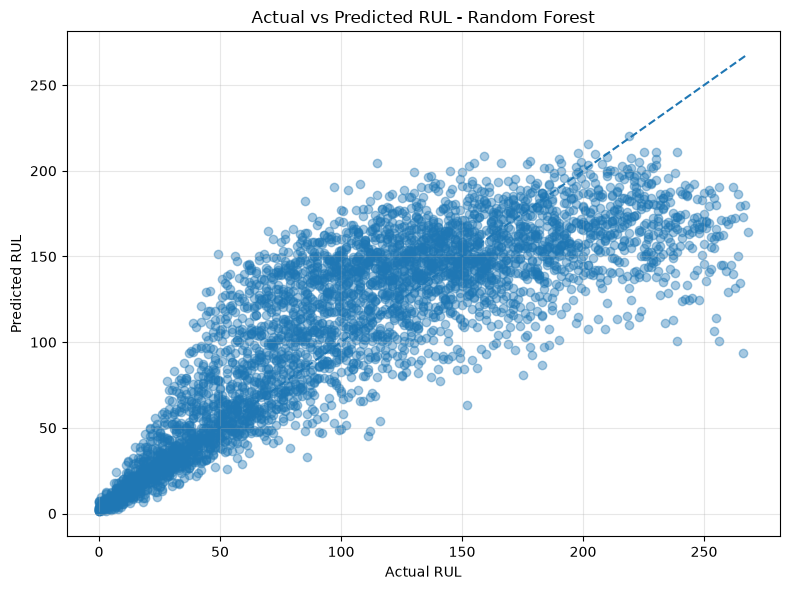

In [14]:
# Plot Actual vs Predicted RUL

plt.figure(figsize=(8, 6))

plt.scatter(
    y_val,
    rf_predictions,
    alpha=0.4
)

# Perfect prediction reference line
min_value = min(y_val.min(), rf_predictions.min())
max_value = max(y_val.max(), rf_predictions.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted RUL - Random Forest")
plt.xlabel("Actual RUL")
plt.ylabel("Predicted RUL")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Calculate Random Forest feature importance

feature_importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_df.head(10)

,Feature,Importance
0,sensor_11,0.487307
1,sensor_9,0.133372
2,sensor_4,0.078096
3,sensor_12,0.043313
4,sensor_14,0.036145
5,sensor_7,0.033212
6,sensor_15,0.027508
7,sensor_21,0.026378
8,sensor_3,0.023659
9,sensor_2,0.022337


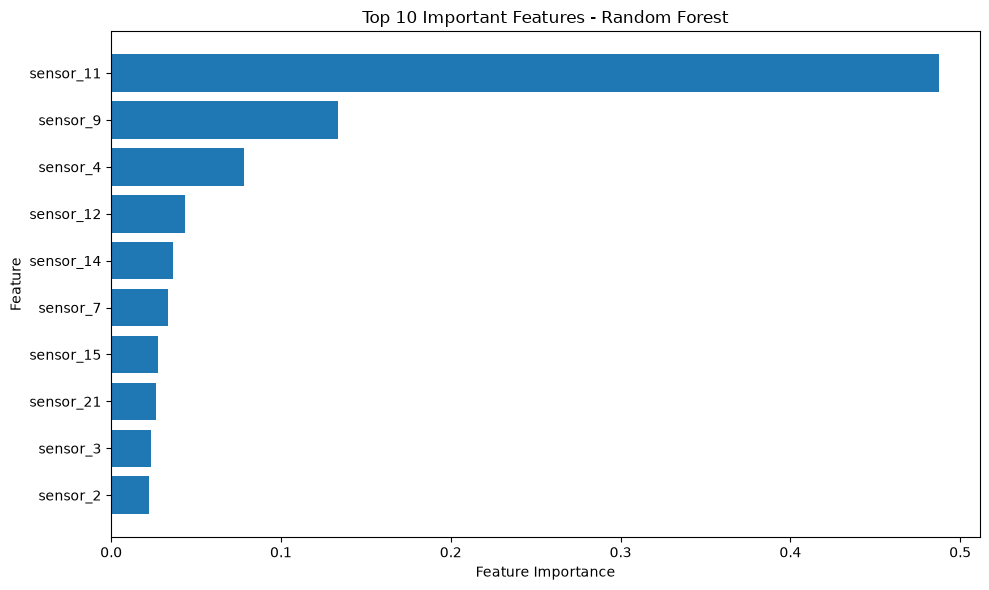

In [16]:
# Plot top 10 most important features

top_features = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features - Random Forest")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### Capped RUL Experiment

In early healthy operation, engines may show very similar sensor behavior even when their exact remaining life differs substantially. Therefore, a capped RUL target is tested by limiting RUL values to a maximum of 125 cycles.

This experiment is evaluated separately from the original uncapped RUL model.

In [17]:
# Create capped RUL targets

RUL_CAP = 125

y_train_capped = y_train.clip(upper=RUL_CAP)
y_val_capped = y_val.clip(upper=RUL_CAP)

print("Original training RUL range:")
print(y_train.min(), "to", y_train.max())

print("\nCapped training RUL range:")
print(y_train_capped.min(), "to", y_train_capped.max())

print("\nNumber of capped training rows:")
print((y_train > RUL_CAP).sum())

Original training RUL range:
0 to 361

Capped training RUL range:
0 to 125

Number of capped training rows:
6481


In [18]:
# Train Random Forest using capped RUL target

rf_capped_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_capped_model.fit(
    X_train,
    y_train_capped
)

print("Capped RUL Random Forest trained successfully!")

Capped RUL Random Forest trained successfully!


In [19]:
# Predict capped RUL

rf_capped_predictions = rf_capped_model.predict(X_val)

# Calculate evaluation metrics
capped_mae = mean_absolute_error(
    y_val_capped,
    rf_capped_predictions
)

capped_rmse = np.sqrt(
    mean_squared_error(
        y_val_capped,
        rf_capped_predictions
    )
)

capped_r2 = r2_score(
    y_val_capped,
    rf_capped_predictions
)

print("===== Capped RUL Random Forest Results =====")
print(f"MAE  : {capped_mae:.2f} cycles")
print(f"RMSE : {capped_rmse:.2f} cycles")
print(f"R²   : {capped_r2:.4f}")

===== Capped RUL Random Forest Results =====
MAE  : 12.35 cycles
RMSE : 17.07 cycles
R²   : 0.8326


In [20]:
# Compare original and capped RUL experiments

rul_experiment_comparison = pd.DataFrame({
    "Experiment": [
        "Original RUL - Random Forest",
        "Capped RUL (125) - Random Forest"
    ],
    "MAE": [
        rf_mae,
        capped_mae
    ],
    "RMSE": [
        rf_rmse,
        capped_rmse
    ],
    "R2": [
        rf_r2,
        capped_r2
    ]
})

rul_experiment_comparison

,Experiment,MAE,RMSE,R2
0,Original RUL - Random Forest,25.874939,35.367672,0.709786
1,Capped RUL (125) - Random Forest,12.352703,17.069440,0.832567


## Final Test Evaluation - FD001

The trained capped-RUL Random Forest model is evaluated on the official FD001 test set.

For each test engine, only its final observed operational cycle is used for prediction. Ground-truth Remaining Useful Life values are obtained from `RUL_FD001.txt`.

In [22]:
# Load FD001 test data and ground-truth RUL values

test_path = "../data/raw/test_FD001.txt"
rul_path = "../data/raw/RUL_FD001.txt"

test_df = pd.read_csv(
    test_path,
    sep=r"\s+",
    header=None
)

true_rul_df = pd.read_csv(
    rul_path,
    sep=r"\s+",
    header=None
)

# Define the 26 column names again in this notebook
column_names = (
    ["unit_id", "cycle"]
    + ["setting_1", "setting_2", "setting_3"]
    + [f"sensor_{i}" for i in range(1, 22)]
)

# Assign column names to test data
test_df.columns = column_names

# Name ground-truth RUL column
true_rul_df.columns = ["true_RUL"]

print("Test data shape:", test_df.shape)
print("Ground-truth RUL shape:", true_rul_df.shape)
print("Number of test engines:", test_df["unit_id"].nunique())

Test data shape: (13096, 26)
Ground-truth RUL shape: (100, 1)
Number of test engines: 100


In [23]:
# Extract the final observed cycle for each test engine

test_last_cycles = (
    test_df
    .sort_values(["unit_id", "cycle"])
    .groupby("unit_id")
    .tail(1)
    .sort_values("unit_id")
    .reset_index(drop=True)
)

print("Final-cycle rows:", test_last_cycles.shape)
test_last_cycles[["unit_id", "cycle"]].head(10)

Final-cycle rows: (100, 26)


,unit_id,cycle
0,1,31
1,2,49
2,3,126
3,4,106
4,5,98
5,6,105
6,7,160
7,8,166
8,9,55
9,10,192


In [24]:
# Prepare test features using the same feature columns

X_test_final = test_last_cycles[feature_columns]

print("Test feature shape:", X_test_final.shape)

# Verify feature consistency
print(
    "Feature order matches training:",
    list(X_test_final.columns) == list(X_train.columns)
)

Test feature shape: (100, 18)
Feature order matches training: True


In [25]:
# Predict RUL for each test engine

test_predictions = rf_capped_model.predict(
    X_test_final
)

# Keep predictions inside capped RUL range
test_predictions = np.clip(
    test_predictions,
    0,
    RUL_CAP
)

print("Number of predictions:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Number of predictions: 100
First 10 predictions:
[118.07276117 117.30514981  66.3440362   99.3121357  101.22502253
 100.77244891 106.94109915 100.94040699 108.33197909 107.61651022]


In [26]:
# Prepare official ground-truth RUL

y_test_true = true_rul_df["true_RUL"].values

# Evaluate capped target consistently
y_test_true_capped = np.minimum(
    y_test_true,
    RUL_CAP
)

test_mae = mean_absolute_error(
    y_test_true_capped,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_true_capped,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test_true_capped,
    test_predictions
)

print("===== Official FD001 Test Results =====")
print(f"MAE  : {test_mae:.2f} cycles")
print(f"RMSE : {test_rmse:.2f} cycles")
print(f"R²   : {test_r2:.4f}")

===== Official FD001 Test Results =====
MAE  : 11.85 cycles
RMSE : 16.78 cycles
R²   : 0.8246


In [27]:
# Prepare final row of each test engine
# Each engine's last available cycle is used for RUL prediction

test_last_cycles = (
    test_df
    .groupby("unit_id")
    .tail(1)
    .copy()
)

print("Final test rows shape:", test_last_cycles.shape)
print("Number of engines:", test_last_cycles["unit_id"].nunique())

test_last_cycles.head()

Final test rows shape: (100, 26)
Number of engines: 100


,unit_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
30,1,31,-0.0006,0.0004,100.0,518.67,642.58,1581.22,1398.91,14.62,...,521.79,2388.06,8130.11,8.4024,0.03,393,2388,100.0,38.81,23.3552
79,2,49,0.0018,-0.0001,100.0,518.67,642.55,1586.59,1410.83,14.62,...,521.74,2388.09,8126.90,8.4505,0.03,391,2388,100.0,38.81,23.2618
205,3,126,-0.0016,0.0004,100.0,518.67,642.88,1589.75,1418.89,14.62,...,520.83,2388.14,8131.46,8.4119,0.03,395,2388,100.0,38.93,23.2740
311,4,106,0.0012,0.0004,100.0,518.67,642.78,1594.53,1406.88,14.62,...,521.88,2388.11,8133.64,8.4634,0.03,395,2388,100.0,38.58,23.2581
409,5,98,-0.0013,-0.0004,100.0,518.67,642.27,1589.94,1419.36,14.62,...,521.00,2388.15,8125.74,8.4362,0.03,394,2388,100.0,38.75,23.4117


In [28]:
# Prepare final test features

X_test_final = test_last_cycles[feature_columns].copy()

print("Final test feature shape:", X_test_final.shape)
print("Number of features:", len(feature_columns))

X_test_final.head()

Final test feature shape: (100, 18)
Number of features: 18


,setting_1,setting_2,setting_3,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21
30,-0.0006,0.0004,100.0,642.58,1581.22,1398.91,21.61,554.42,2388.08,9056.40,47.23,521.79,2388.06,8130.11,8.4024,393,38.81,23.3552
79,0.0018,-0.0001,100.0,642.55,1586.59,1410.83,21.61,553.52,2388.10,9044.77,47.67,521.74,2388.09,8126.90,8.4505,391,38.81,23.2618
205,-0.0016,0.0004,100.0,642.88,1589.75,1418.89,21.61,552.59,2388.16,9049.26,47.88,520.83,2388.14,8131.46,8.4119,395,38.93,23.2740
311,0.0012,0.0004,100.0,642.78,1594.53,1406.88,21.61,552.64,2388.13,9051.30,47.65,521.88,2388.11,8133.64,8.4634,395,38.58,23.2581
409,-0.0013,-0.0004,100.0,642.27,1589.94,1419.36,21.61,553.29,2388.10,9053.99,47.46,521.00,2388.15,8125.74,8.4362,394,38.75,23.4117


In [29]:
# Predict RUL for the 100 test engines

test_predictions = rf_capped_model.predict(X_test_final)

# Keep predictions within valid capped RUL range
test_predictions = np.clip(test_predictions, 0, 125)

print("Number of predictions:", len(test_predictions))
print("Prediction range:")
print("Min:", test_predictions.min())
print("Max:", test_predictions.max())

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Number of predictions: 100
Prediction range:
Min: 6.4971411878815255
Max: 123.52059450501933

First 10 predictions:
[118.07276117 117.30514981  66.3440362   99.3121357  101.22502253
 100.77244891 106.94109915 100.94040699 108.33197909 107.61651022]


In [30]:
# Final evaluation on official FD001 test set

# Extract true RUL values
y_test_true = true_rul_df["true_RUL"].values

# Safety check
print("True RUL count:", len(y_test_true))
print("Prediction count:", len(test_predictions))

assert len(y_test_true) == len(test_predictions), \
    "Mismatch between true RUL values and predictions!"

# Calculate final test metrics
test_mae = mean_absolute_error(
    y_test_true,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test_true,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test_true,
    test_predictions
)

print("\n===== FINAL FD001 TEST RESULTS =====")
print(f"MAE  : {test_mae:.2f} cycles")
print(f"RMSE : {test_rmse:.2f} cycles")
print(f"R²   : {test_r2:.4f}")

True RUL count: 100
Prediction count: 100

===== FINAL FD001 TEST RESULTS =====
MAE  : 12.92 cycles
RMSE : 17.75 cycles
R²   : 0.8175


In [31]:
import joblib
import os

# Create models directory if it does not exist
os.makedirs("../models", exist_ok=True)

# Save best trained model
joblib.dump(
    rf_capped_model,
    "../models/rf_capped_fd001.pkl"
)

# Save exact feature columns used by the model
joblib.dump(
    feature_columns,
    "../models/feature_columns_fd001.pkl"
)

print("Model saved successfully!")
print("Feature columns saved successfully!")
print("Number of saved features:", len(feature_columns))

Model saved successfully!
Feature columns saved successfully!
Number of saved features: 18


## Final Test Results Visualization

The following analysis compares predicted Remaining Useful Life values against the ground-truth RUL values provided for the 100 FD001 test engines.

In [32]:
# Create final test results DataFrame

test_results_df = pd.DataFrame({
    "Engine_ID": test_last_cycles["unit_id"].values,
    "Actual_RUL": y_test_true,
    "Predicted_RUL": test_predictions
})

# Calculate absolute prediction error
test_results_df["Absolute_Error"] = abs(
    test_results_df["Actual_RUL"]
    - test_results_df["Predicted_RUL"]
)

print("Test results shape:", test_results_df.shape)

test_results_df.head(10)

Test results shape: (100, 4)


,Engine_ID,Actual_RUL,Predicted_RUL,Absolute_Error
0,1,112,118.072761,6.072761
1,2,98,117.305150,19.305150
2,3,69,66.344036,2.655964
3,4,82,99.312136,17.312136
4,5,91,101.225023,10.225023
5,6,93,100.772449,7.772449
6,7,91,106.941099,15.941099
7,8,95,100.940407,5.940407
8,9,111,108.331979,2.668021
9,10,96,107.616510,11.616510


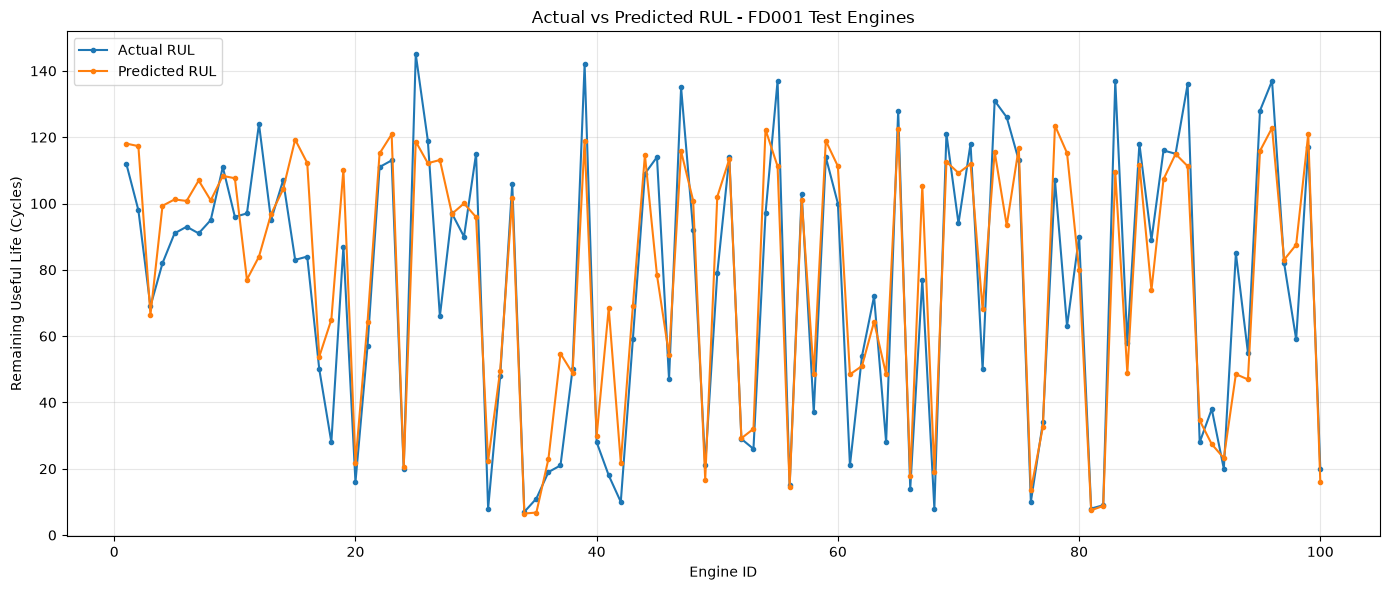

In [36]:
# Plot Actual vs Predicted RUL for all test engines

plt.figure(figsize=(14, 6))

plt.plot(
    test_results_df["Engine_ID"],
    test_results_df["Actual_RUL"],
    label="Actual RUL",
    marker="o",
    markersize=3
)

plt.plot(
    test_results_df["Engine_ID"],
    test_results_df["Predicted_RUL"],
    label="Predicted RUL",
    marker="o",
    markersize=3
)

plt.title("Actual vs Predicted RUL - FD001 Test Engines")
plt.xlabel("Engine ID")
plt.ylabel("Remaining Useful Life (Cycles)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/figures/actual_vs_predicted_rul.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

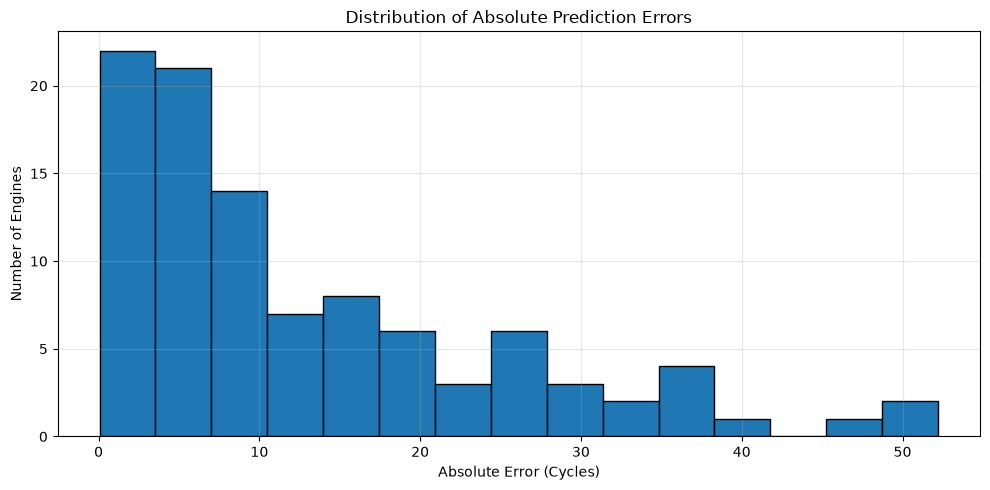

In [37]:
# Plot prediction error distribution

plt.figure(figsize=(10, 5))

plt.hist(
    test_results_df["Absolute_Error"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Absolute Prediction Errors")
plt.xlabel("Absolute Error (Cycles)")
plt.ylabel("Number of Engines")
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../reports/figures/absolute_error_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

In [38]:
# Save final test predictions

results_path = "../reports/fd001_test_predictions.csv"

test_results_df.to_csv(
    results_path,
    index=False
)

print("Test predictions saved successfully!")
print("Saved at:", results_path)

Test predictions saved successfully!
Saved at: ../reports/fd001_test_predictions.csv
